Image size : 672 rows × 895 cols × 426 bands
Expected size : 672 rows × 895 cols

Total valid samples: 466

Pixel count per class:
bare            : 50
built-up        : 48
cropland        : 50
grassland       : 48
greenhouse      : 112
paddy-field     : 50
solar-panel     : 62
water           : 46


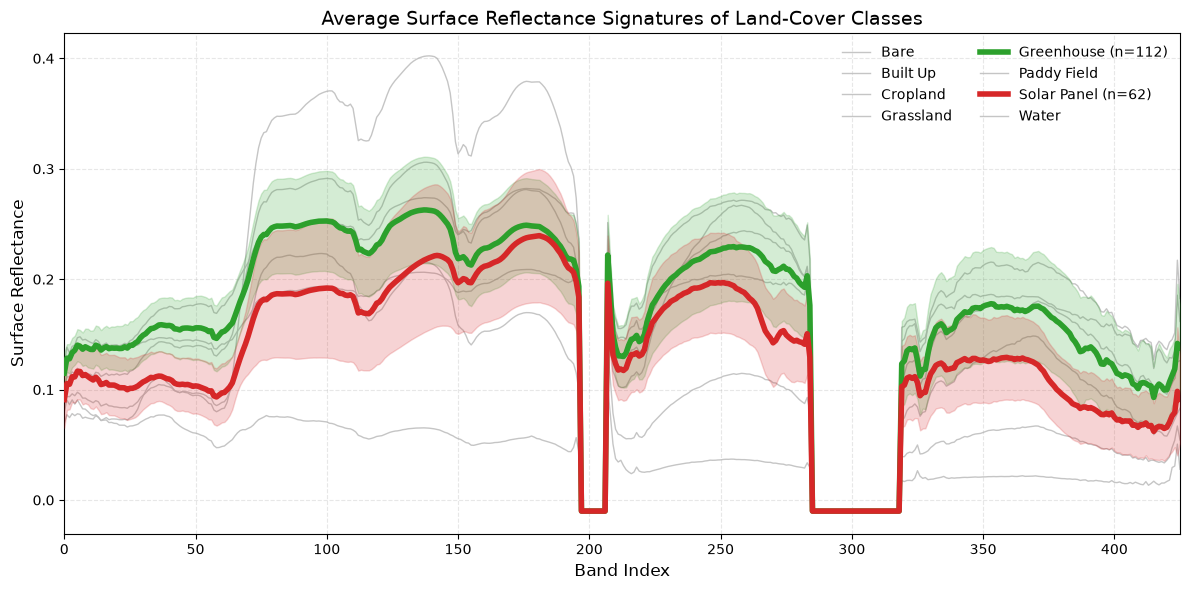

In [10]:
# =============================================================================
# TANAGER HYPERSPECTRAL: SURFACE REFLECTANCE ANALYSIS
# =============================================================================

from pathlib import Path
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import h5py
from affine import Affine
from rasterio.features import rasterize

# ==========================================================
# CONFIGURATION
# ==========================================================
HDF5_FILE = Path("/Volumes/Backup/UNIVERSITY_OF_TSUKUBA/WUN RDF 2026/20250503_020525_16_4001_ortho_sr_hdf5.h5")
POLY_FOLDER = Path(".")

CLASSES = [
    "bare",
    "built-up",
    "cropland",
    "grassland",
    "greenhouse",
    "paddy-field",
    "solar-panel",
    "water"
]

class_to_id = {c: i + 1 for i, c in enumerate(CLASSES)}

# ==========================================================
# LOAD DATA
# ==========================================================
with h5py.File(HDF5_FILE, "r") as f:

    cube = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["surface_reflectance"][:]
    cube = np.moveaxis(cube, 0, -1)

    cloud = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["beta_cloud_mask"][:]
    cirrus = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["beta_cirrus_mask"][:]
    nodata = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["nodata_pixels"][:]

rows, cols, bands = cube.shape

print(f"Image size : {rows} rows × {cols} cols × {bands} bands")

# ==========================================================
# IMAGE GEOREFERENCE
# ==========================================================
upper_left_x = 666390.0
upper_left_y = 3870480.0
lower_right_x = 693240.0
lower_right_y = 3850320.0
pixel_size = 30.0

expected_cols = int((lower_right_x - upper_left_x) / pixel_size)
expected_rows = int((upper_left_y - lower_right_y) / pixel_size)

print(f"Expected size : {expected_rows} rows × {expected_cols} cols")

assert rows == expected_rows, "Row mismatch!"
assert cols == expected_cols, "Column mismatch!"

transform = Affine(
    pixel_size, 0, upper_left_x,
    0, -pixel_size, upper_left_y
)

# ==========================================================
# VALID PIXELS
# ==========================================================
valid_mask = (cloud == 0) & (cirrus == 0) & (nodata == 0)

# ==========================================================
# LOAD POLYGONS
# ==========================================================
label_map = np.zeros((rows, cols), dtype=np.uint8)

for cls in CLASSES:

    shp = POLY_FOLDER / f"{cls}.geojson"

    if not shp.exists():
        print(f"Missing: {shp}")
        continue

    gdf = gpd.read_file(shp).to_crs("EPSG:32653")

    shapes = [
        (geom, class_to_id[cls])
        for geom in gdf.geometry
        if geom is not None and not geom.is_empty
    ]

    if len(shapes) == 0:
        continue

    raster = rasterize(
        shapes=shapes,
        out_shape=(rows, cols),
        transform=transform,
        fill=0,
        dtype=np.uint8
    )

    label_map = np.maximum(label_map, raster)

# ==========================================================
# EXTRACT TRAINING PIXELS
# ==========================================================
X = cube.reshape(-1, bands)
labels = label_map.ravel()
valid = valid_mask.ravel()

mask = (labels > 0) & valid

X = X[mask]
y = labels[mask]

print(f"\nTotal valid samples: {len(y):,}")

# ==========================================================
# COMPUTE MEAN SPECTRA
# ==========================================================
spectra = {}

for cls, cid in class_to_id.items():

    Xc = X[y == cid]

    if len(Xc) == 0:
        print(f"Warning: {cls} has no pixels.")
        continue

    spectra[cls] = {
        "mean": Xc.mean(axis=0),
        "std": Xc.std(axis=0),
        "n": len(Xc)
    }

print("\nPixel count per class:")
for cls, s in spectra.items():
    print(f"{cls:<15} : {s['n']}")

# ==========================================================
# PLOT (Highlight Solar Panel & Greenhouse)
# ==========================================================
plt.figure(figsize=(12, 6))

x = np.arange(bands)

highlight = {
    "solar-panel": {
        "color": "#d62728",
        "linewidth": 4.0,
        "alpha": 1.0
    },
    "greenhouse": {
        "color": "#2ca02c",
        "linewidth": 4.0,
        "alpha": 1.0
    }
}

for cls, s in spectra.items():

    mean = s["mean"]
    std = s["std"]

    if cls in highlight:

        style = highlight[cls]

        plt.plot(
            x,
            mean,
            color=style["color"],
            linewidth=style["linewidth"],
            label=f"{cls.replace('-', ' ').title()} (n={s['n']})",
            zorder=10
        )

        plt.fill_between(
            x,
            mean - std,
            mean + std,
            color=style["color"],
            alpha=0.20,
            zorder=9
        )

    else:

        plt.plot(
            x,
            mean,
            color="0.75",
            linewidth=1.0,
            alpha=0.9,
            label=cls.replace("-", " ").title(),
            zorder=1
        )

plt.xlabel("Band Index", fontsize=12)
plt.ylabel("Surface Reflectance", fontsize=12)
plt.title("Average Surface Reflectance Signatures of Land-Cover Classes", fontsize=14)

plt.xlim(0, bands - 1)

plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(
    frameon=False,
    fontsize=10,
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "spectral_signatures_highlighted.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

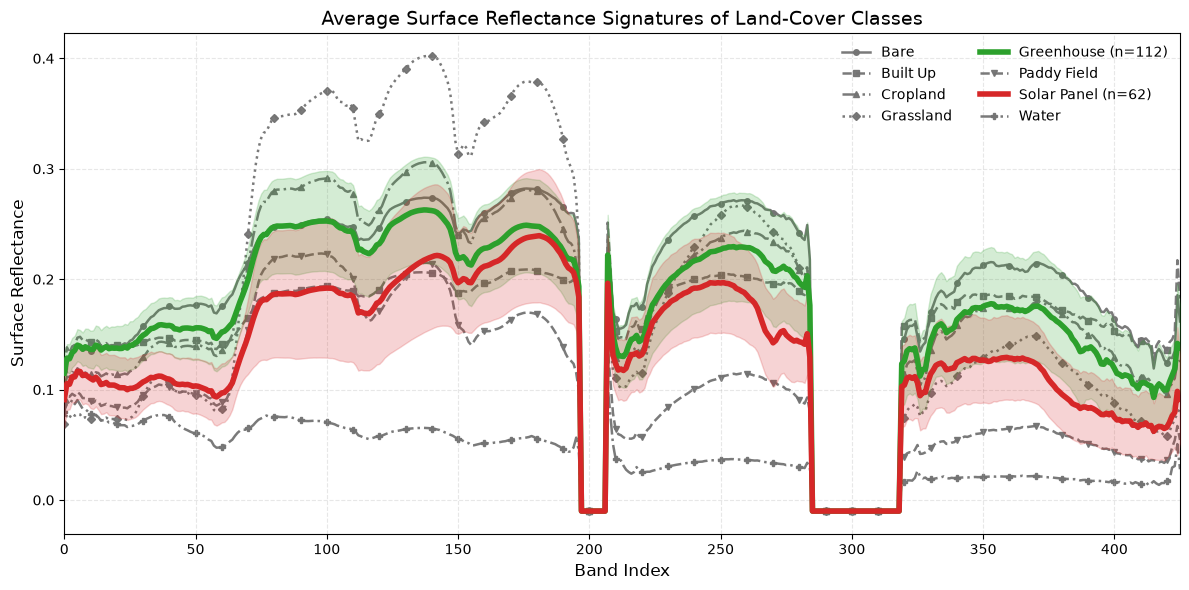

In [12]:
# ==========================================================
# PLOT (Highlight Solar Panel & Greenhouse)
# ==========================================================
plt.figure(figsize=(12, 6))

x = np.arange(bands)

# Highlighted classes (unchanged)
highlight = {
    "solar-panel": {
        "color": "#d62728",
        "linewidth": 4.0,
        "alpha": 1.0
    },
    "greenhouse": {
        "color": "#2ca02c",
        "linewidth": 4.0,
        "alpha": 1.0
    }
}

# Styles for remaining classes
other_styles = {
    "bare":         {"linestyle": "-",  "marker": "o"},
    "built-up":     {"linestyle": "--", "marker": "s"},
    "cropland":     {"linestyle": "-.", "marker": "^"},
    "grassland":    {"linestyle": ":",  "marker": "D"},
    "paddy-field":  {"linestyle": "--", "marker": "v"},
    "water":        {"linestyle": "-.", "marker": "P"},
}

for cls, s in spectra.items():

    mean = s["mean"]
    std = s["std"]

    if cls in highlight:

        style = highlight[cls]

        plt.plot(
            x,
            mean,
            color=style["color"],
            linewidth=style["linewidth"],
            label=f"{cls.replace('-', ' ').title()} (n={s['n']})",
            zorder=10
        )

        plt.fill_between(
            x,
            mean - std,
            mean + std,
            color=style["color"],
            alpha=0.20,
            zorder=9
        )

    else:

        style = other_styles[cls]

        plt.plot(
            x,
            mean,
            color="0.45",
            linewidth=1.8,
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=4,
            markevery=10,   # marker every 10 bands
            alpha=0.95,
            label=cls.replace("-", " ").title(),
            zorder=1
        )

plt.xlabel("Band Index", fontsize=12)
plt.ylabel("Surface Reflectance", fontsize=12)
plt.title("Average Surface Reflectance Signatures of Land-Cover Classes", fontsize=14)

plt.xlim(0, bands - 1)

plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(
    frameon=False,
    fontsize=10,
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "spectral_signatures_highlighted_new.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Cube shape: (672, 895, 426)
Transform:
| 30.00, 0.00, 666390.00|
| 0.00,-30.00, 3870480.00|
| 0.00, 0.00, 1.00|
Extent: X = [666390.0, 693240.0]
        Y = [3850320.0, 3870480.0]
Training samples : 220,304
Testing samples  : 94,416
PCA completed.
Prediction finished.
Majority filtering finished.


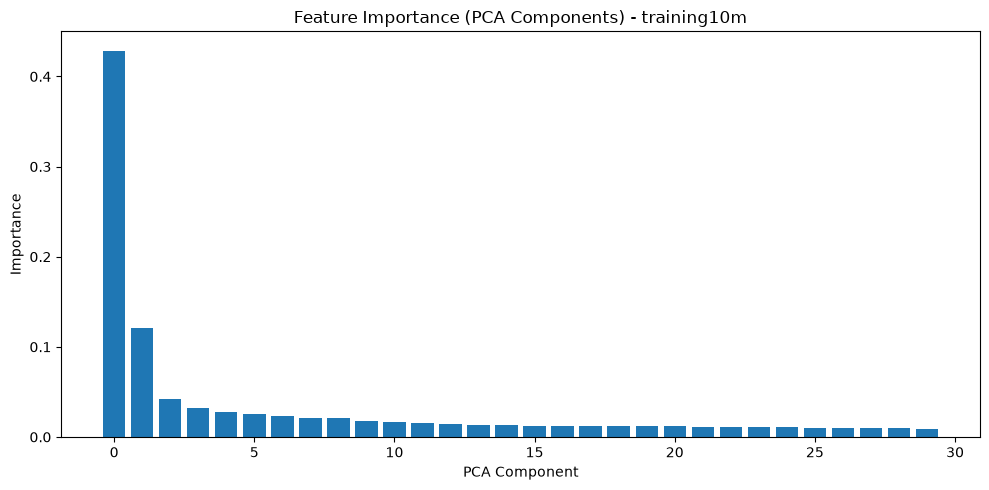

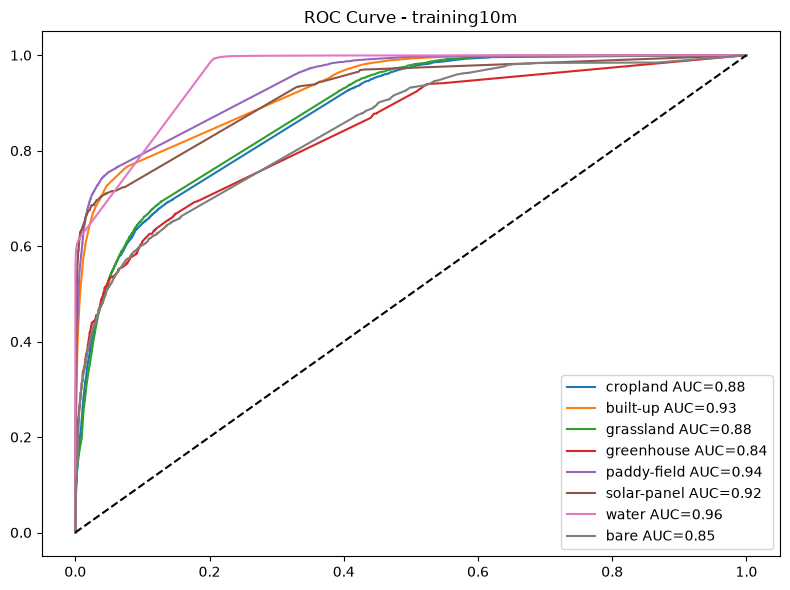

Retraining using all labeled samples...
Valid pixels : 433,408
Background   : 168,032
Prediction finished.
Majority filtering finished.
Saved GeoTIFF: majority_map_training10m.tif


In [ ]:
# =============================================================================
# TANAGER HYPERSPECTRAL CLASSIFICATION: USING 10M TRAINING DATASETS
# =============================================================================

import numpy as np
import h5py
import geopandas as gpd
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import rasterio
from rasterio.features import rasterize
from rasterio.transform import Affine
from rasterio.crs import CRS

from scipy.ndimage import generic_filter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    cohen_kappa_score,
)

# =============================================================================
# CONFIG
# =============================================================================

DATA_PATH = r"/Volumes/Backup/UNIVERSITY_OF_TSUKUBA/WUN RDF 2026/20250503_020525_16_4001_ortho_sr_hdf5.h5"
POLY_FOLDER = Path(r"/Volumes/Backup/UNIVERSITY_OF_TSUKUBA/WUN RDF 2026")

CLASSES = [
    "cropland_only","built-up_only","grassland_only","greenhouse_only",
    "paddy-field_only","solar-panel_only","water_only","bare_only"
]

class_to_id = {c: i + 1 for i, c in enumerate(CLASSES)}
id_to_class = {v: k for k, v in class_to_id.items()}

def clean(c):
    return c.replace("_only", "")

color_map = {
    "cropland": "#FFB6C1",
    "built-up": "#FF0000",
    "grassland": "#FFFF00",
    "greenhouse": "#FFFFFF",
    "paddy-field": "#0000FF",
    "solar-panel": "#800080",
    "water": "#00008B",
    "bare": "#D2B48C"
}

# =============================================================================
# LOAD DATA
# =============================================================================

with h5py.File(DATA_PATH, "r") as f:

    cube = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["surface_reflectance"][:]

    # Convert from (bands, rows, cols) -> (rows, cols, bands)
    cube = np.moveaxis(cube, 0, -1)

h, w, b = cube.shape

print(f"Cube shape: {cube.shape}")

X_full = cube.reshape(-1, b)

# =============================================================================
# LABELS
# =============================================================================

gdfs = {}
for cls in CLASSES:
    gdfs[cls] = gpd.read_file(POLY_FOLDER / f"{cls}.geojson").to_crs("EPSG:32653")

# =============================================================================
# IMAGE GEOREFERENCE (EPSG:32653)
# Metadata:
# UpperLeftPointMtrs = (666390.00, 3870480.00)
# LowerRightMtrs = (693240.00, 3850320.00)
# =============================================================================

min_x = 666390.0
max_x = 693240.0
min_y = 3850320.0
max_y = 3870480.0

pixel_size = 30.0

# Verify image dimensions from metadata
expected_cols = int((max_x - min_x) / pixel_size)
expected_rows = int((max_y - min_y) / pixel_size)

assert w == expected_cols, f"Expected {expected_cols} columns, got {w}"
assert h == expected_rows, f"Expected {expected_rows} rows, got {h}"

# Affine transform
transform = Affine(
    pixel_size, 0.0, min_x,
    0.0, -pixel_size, max_y
)

print("Transform:")
print(transform)
print(f"Extent: X = [{min_x:.1f}, {max_x:.1f}]")
print(f"        Y = [{min_y:.1f}, {max_y:.1f}]")

label_map = np.zeros((h, w), dtype=np.uint8)

for cls, gdf in gdfs.items():
    shapes = [(geom, class_to_id[cls]) for geom in gdf.geometry]
    mask = rasterize(shapes, out_shape=(h, w), transform=transform, fill=0, dtype=np.uint8)
    label_map = np.maximum(label_map, mask)

y_full = label_map.reshape(-1)
mask = y_full > 0

X = X_full[mask]
y = y_full[mask]

# =============================================================================
# TRAIN / TEST SPLIT (NO DATA LEAKAGE)
# =============================================================================

indices = np.arange(len(X))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train = X[train_idx]
X_test  = X[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

print(f"Training samples : {len(y_train):,}")
print(f"Testing samples  : {len(y_test):,}")

# =============================================================================
# PREPROCESSING (TRAIN ONLY)
# =============================================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=30)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA completed.")

# =============================================================================
# MAJORITY FILTER
# =============================================================================

def majority_filter(img, size=5):
    """
    Apply a majority (mode) filter to a classified image.

    Parameters
    ----------
    img : ndarray
        Classified image.
    size : int
        Moving window size (must be odd).

    Returns
    -------
    ndarray
        Smoothed classified image.
    """
    def fn(x):
        vals, counts = np.unique(x, return_counts=True)
        return vals[np.argmax(counts)]

    return generic_filter(img, fn, size=size)

# =============================================================================
# RANDOM FOREST CLASSIFIER
# =============================================================================

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_pca, y_train)

pred = rf.predict(X_test_pca)

# =============================================================================
# FULL IMAGE PREDICTION
# =============================================================================

X_full_scaled = scaler.transform(X_full)
X_full_pca = pca.transform(X_full_scaled)

pred_map = rf.predict(X_full_pca).reshape(h, w)

print("Prediction finished.")

# =============================================================================
# APPLY MAJORITY FILTER
# =============================================================================

pred_majority = majority_filter(pred_map, size=5)

print("Majority filtering finished.")

# =============================================================================
# FEATURE IMPORTANCE PLOT
# =============================================================================

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[idx])
plt.title("Feature Importance (PCA Components) - training10m")
plt.xlabel("PCA Component")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_training10m.png", dpi=600)
plt.show()

# =============================================================================
# ROC CURVE (MULTICLASS)
# =============================================================================

y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = rf.predict_proba(X_test_pca)

plt.figure(figsize=(8, 6))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clean(id_to_class[i+1])} AUC={roc_auc:.2f}")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve - training10m")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_training10m.png", dpi=600)
plt.show()

# =============================================================================
# FINAL MODEL + BACKGROUND MASKING + EXPORT
# =============================================================================

print("Retraining using all labeled samples...")

# ---------------------------------------------------------------------
# Train final model
# ---------------------------------------------------------------------

scaler_final = StandardScaler()
X_scaled_all = scaler_final.fit_transform(X)

pca_final = PCA(n_components=30)
X_pca_all = pca_final.fit_transform(X_scaled_all)

rf_final = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_pca_all, y)

# ---------------------------------------------------------------------
# VALID PIXEL MASK
# Background pixels in Tanager-1 = -9999
# ---------------------------------------------------------------------

fill_value = -9999.0

valid_mask = ~np.any(np.isclose(cube, fill_value), axis=2)

print(f"Valid pixels : {valid_mask.sum():,}")
print(f"Background   : {(~valid_mask).sum():,}")

# ---------------------------------------------------------------------
# Predict ONLY valid pixels
# ---------------------------------------------------------------------

X_valid = X_full[valid_mask.ravel()]

X_valid_scaled = scaler_final.transform(X_valid)
X_valid_pca = pca_final.transform(X_valid_scaled)

pred_valid = rf_final.predict(X_valid_pca)

# Initialize output with background (0 = NoData)

pred_map = np.zeros((h, w), dtype=np.uint8)

pred_map.ravel()[valid_mask.ravel()] = pred_valid

print("Prediction finished.")

# ---------------------------------------------------------------------
# Majority filtering
# ---------------------------------------------------------------------

pred_majority = majority_filter(pred_map, size=5)

# Preserve NoData background
pred_majority[~valid_mask] = 0

print("Majority filtering finished.")

# ---------------------------------------------------------------------
# Export GeoTIFF
# ---------------------------------------------------------------------

out_path = "majority_map_training10m.tif"

with rasterio.open(
    out_path,
    "w",
    driver="GTiff",
    height=h,
    width=w,
    count=1,
    dtype=np.uint8,
    crs=CRS.from_epsg(32653),
    transform=transform,
    nodata=0,
) as dst:
    dst.write(pred_majority, 1)

print("Saved GeoTIFF:", out_path)

# ---------------------------------------------------------------------
# Color Lookup Table
# ---------------------------------------------------------------------

lut = np.zeros((len(CLASSES)+1, 3), dtype=float)

# Background (NoData)
lut[0] = [0, 0, 0]

for cls, idx in class_to_id.items():
    lut[idx] = mcolors.to_rgb(color_map[clean(cls)])

def to_rgb(img):
    return lut[img]

rgb_original = to_rgb(pred_map)
rgb_majority = to_rgb(pred_majority)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

left = transform.c
top = transform.f
right = left + w * transform.a
bottom = top + h * transform.e
extent = [left, right, bottom, top]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(rgb_original, extent=extent)
axes[0].set_title("Original Random Forest")

axes[1].imshow(rgb_majority, extent=extent)
axes[1].set_title("Majority Filter")

for ax in axes:
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

legend = [
    mpatches.Patch(color=color_map[clean(c)], label=clean(c))
    for c in CLASSES
]

fig.legend(
    handles=legend,
    loc="center right",
    bbox_to_anchor=(1.12, 0.5)
)

plt.tight_layout()
plt.savefig("original_vs_majority_training10m.png", dpi=600)
plt.show()

# Save for comparison
pred_map_10 = pred_map.copy()
pred_majority_10 = pred_majority.copy()

Prediction finished.
Majority filtering finished.


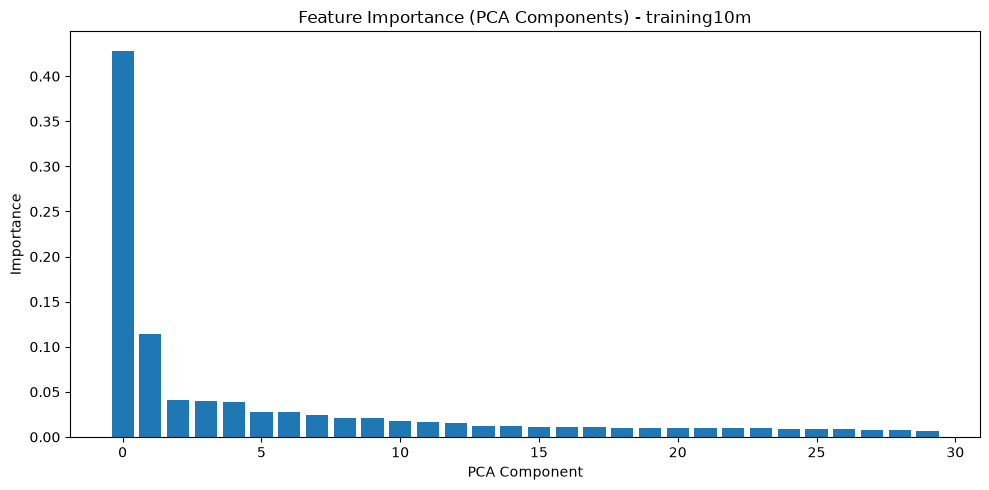

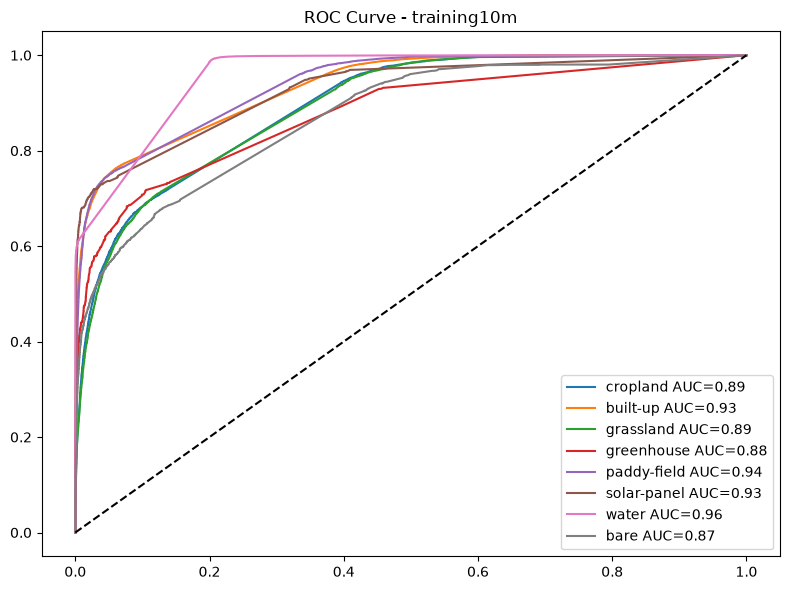

Retraining using all labeled samples...
Valid pixels : 433,408
Background   : 168,032
Prediction finished.
Majority filtering finished.
Saved GeoTIFF: majority_map_training50m.tif


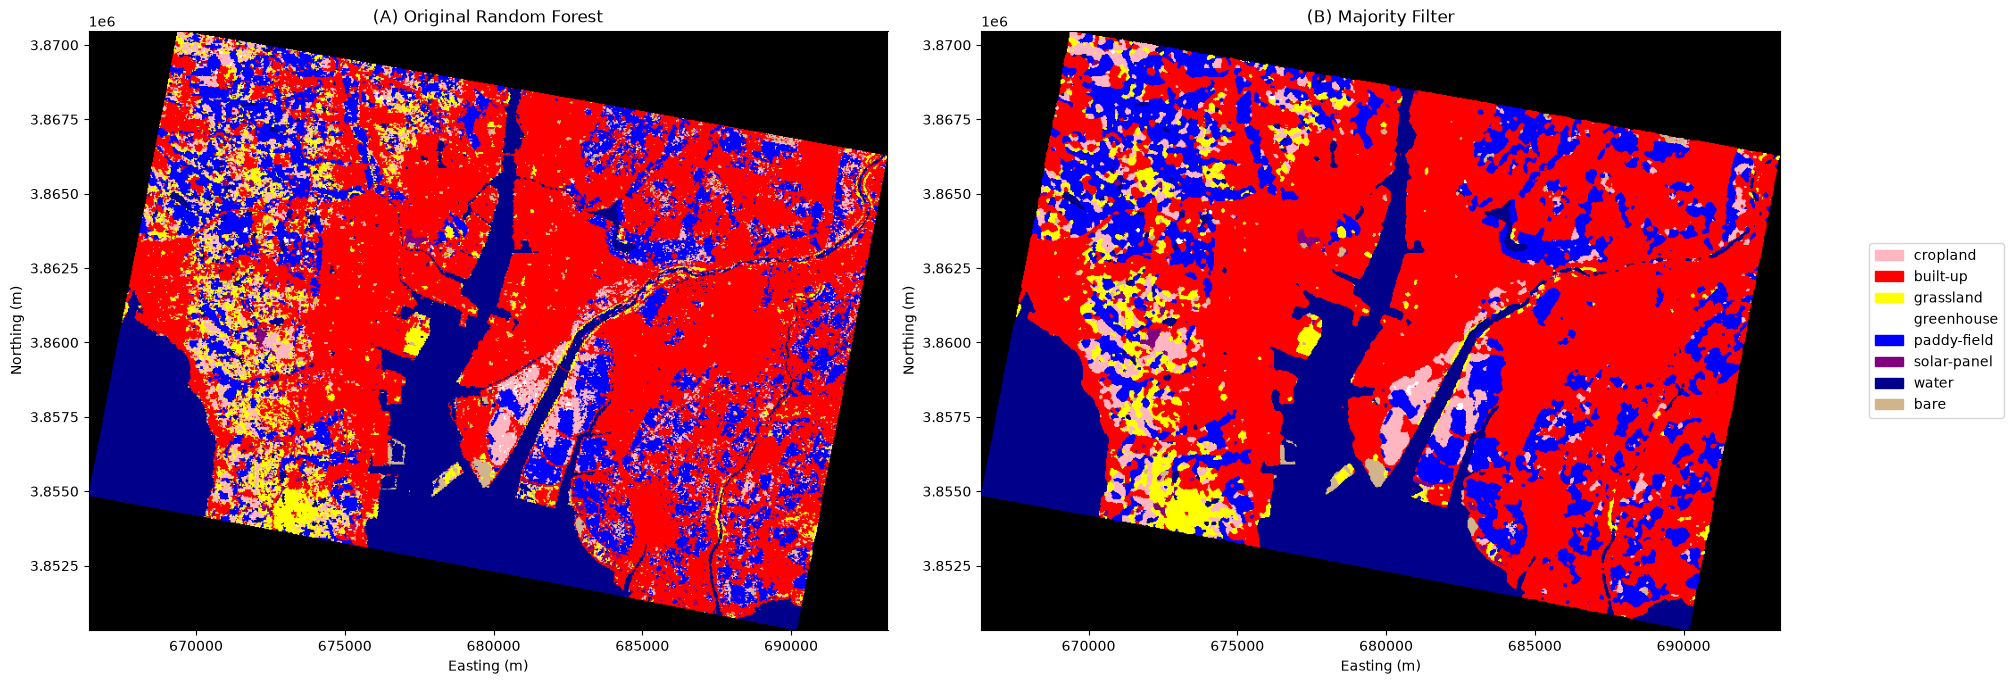

In [14]:
# =============================================================================
# TANAGER HYPERSPECTRAL CLASSIFICATION: USING 50M TRAINING DATASETS
# =============================================================================

import numpy as np
import h5py
import geopandas as gpd
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import rasterio
from rasterio.features import rasterize
from rasterio.transform import Affine
from rasterio.crs import CRS

from scipy.ndimage import generic_filter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    cohen_kappa_score,
)

# =============================================================================
# CONFIG
# =============================================================================

DATA_PATH = r"/Volumes/Backup/UNIVERSITY_OF_TSUKUBA/WUN RDF 2026/20250503_020525_16_4001_ortho_sr_hdf5.h5"
POLY_FOLDER = Path(r"/Volumes/Backup/UNIVERSITY_OF_TSUKUBA/WUN RDF 2026/training_50m")

CLASSES = [
    "cropland","built-up","grassland","greenhouse",
    "paddy-field","solar-panel","water","bare"
]

class_to_id = {c: i + 1 for i, c in enumerate(CLASSES)}
id_to_class = {v: k for k, v in class_to_id.items()}

def clean(c):
    return c.replace("_only", "")

color_map = {
    "cropland": "#FFB6C1",
    "built-up": "#FF0000",
    "grassland": "#FFFF00",
    "greenhouse": "#FFFFFF",
    "paddy-field": "#0000FF",
    "solar-panel": "#800080",
    "water": "#00008B",
    "bare": "#D2B48C"
}

# =============================================================================
# LOAD DATA
# =============================================================================

with h5py.File(DATA_PATH, "r") as f:

    cube = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["surface_reflectance"][:]

    # Convert from (bands, rows, cols) -> (rows, cols, bands)
    cube = np.moveaxis(cube, 0, -1)

h, w, b = cube.shape

print(f"Cube shape: {cube.shape}")

X_full = cube.reshape(-1, b)

# =============================================================================
# LABELS
# =============================================================================

gdfs = {}
for cls in CLASSES:
    gdfs[cls] = gpd.read_file(POLY_FOLDER / f"{cls}.geojson").to_crs("EPSG:32653")

# =============================================================================
# IMAGE GEOREFERENCE (EPSG:32653)
# Metadata:
# UpperLeftPointMtrs = (666390.00, 3870480.00)
# LowerRightMtrs = (693240.00, 3850320.00)
# =============================================================================

min_x = 666390.0
max_x = 693240.0
min_y = 3850320.0
max_y = 3870480.0

pixel_size = 30.0

# Verify image dimensions from metadata
expected_cols = int((max_x - min_x) / pixel_size)
expected_rows = int((max_y - min_y) / pixel_size)

assert w == expected_cols, f"Expected {expected_cols} columns, got {w}"
assert h == expected_rows, f"Expected {expected_rows} rows, got {h}"

# Affine transform
transform = Affine(
    pixel_size, 0.0, min_x,
    0.0, -pixel_size, max_y
)

print("Transform:")
print(transform)
print(f"Extent: X = [{min_x:.1f}, {max_x:.1f}]")
print(f"        Y = [{min_y:.1f}, {max_y:.1f}]")

label_map = np.zeros((h, w), dtype=np.uint8)

for cls, gdf in gdfs.items():
    shapes = [(geom, class_to_id[cls]) for geom in gdf.geometry]
    mask = rasterize(shapes, out_shape=(h, w), transform=transform, fill=0, dtype=np.uint8)
    label_map = np.maximum(label_map, mask)

y_full = label_map.reshape(-1)
mask = y_full > 0

X = X_full[mask]
y = y_full[mask]

# =============================================================================
# TRAIN / TEST SPLIT (NO DATA LEAKAGE)
# =============================================================================

indices = np.arange(len(X))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train = X[train_idx]
X_test  = X[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

print(f"Training samples : {len(y_train):,}")
print(f"Testing samples  : {len(y_test):,}")

# =============================================================================
# PREPROCESSING (TRAIN ONLY)
# =============================================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=30)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA completed.")

# =============================================================================
# MAJORITY FILTER
# =============================================================================

def majority_filter(img, size=5):
    """
    Apply a majority (mode) filter to a classified image.

    Parameters
    ----------
    img : ndarray
        Classified image.
    size : int
        Moving window size (must be odd).

    Returns
    -------
    ndarray
        Smoothed classified image.
    """
    def fn(x):
        vals, counts = np.unique(x, return_counts=True)
        return vals[np.argmax(counts)]

    return generic_filter(img, fn, size=size)

# =============================================================================
# RANDOM FOREST CLASSIFIER
# =============================================================================

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_pca, y_train)

pred = rf.predict(X_test_pca)

# =============================================================================
# FULL IMAGE PREDICTION
# =============================================================================

X_full_scaled = scaler.transform(X_full)
X_full_pca = pca.transform(X_full_scaled)

pred_map = rf.predict(X_full_pca).reshape(h, w)

print("Prediction finished.")

# =============================================================================
# APPLY MAJORITY FILTER
# =============================================================================

pred_majority = majority_filter(pred_map, size=5)

print("Majority filtering finished.")

# =============================================================================
# FEATURE IMPORTANCE PLOT
# =============================================================================

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[idx])
plt.title("Feature Importance (PCA Components) - training10m")
plt.xlabel("PCA Component")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_training10m.png", dpi=600)
plt.show()

# =============================================================================
# ROC CURVE (MULTICLASS)
# =============================================================================

y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = rf.predict_proba(X_test_pca)

plt.figure(figsize=(8, 6))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clean(id_to_class[i+1])} AUC={roc_auc:.2f}")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve - training10m")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_training10m.png", dpi=600)
plt.show()

# =============================================================================
# FINAL MODEL + BACKGROUND MASKING + EXPORT (50 m Training)
# =============================================================================

print("Retraining using all labeled samples...")

# ---------------------------------------------------------------------
# Train final model
# ---------------------------------------------------------------------

scaler_final = StandardScaler()
X_scaled_all = scaler_final.fit_transform(X)

pca_final = PCA(n_components=30)
X_pca_all = pca_final.fit_transform(X_scaled_all)

rf_final = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_pca_all, y)

# ---------------------------------------------------------------------
# VALID PIXEL MASK
# Background pixels in Tanager-1 = -9999
# ---------------------------------------------------------------------

fill_value = -9999.0

valid_mask = ~np.any(np.isclose(cube, fill_value), axis=2)

print(f"Valid pixels : {valid_mask.sum():,}")
print(f"Background   : {(~valid_mask).sum():,}")

# ---------------------------------------------------------------------
# Predict ONLY valid pixels
# ---------------------------------------------------------------------

X_valid = X_full[valid_mask.ravel()]

X_valid_scaled = scaler_final.transform(X_valid)
X_valid_pca = pca_final.transform(X_valid_scaled)

pred_valid = rf_final.predict(X_valid_pca)

# Initialize prediction map with NoData (0)

pred_map = np.zeros((h, w), dtype=np.uint8)

pred_map.ravel()[valid_mask.ravel()] = pred_valid

print("Prediction finished.")

# ---------------------------------------------------------------------
# Majority filtering
# ---------------------------------------------------------------------

pred_majority = majority_filter(pred_map, size=5)

# Preserve background as NoData
pred_majority[~valid_mask] = 0

print("Majority filtering finished.")

# ---------------------------------------------------------------------
# Export GeoTIFF
# ---------------------------------------------------------------------

out_path = "majority_map_training50m.tif"

with rasterio.open(
    out_path,
    "w",
    driver="GTiff",
    height=h,
    width=w,
    count=1,
    dtype=np.uint8,
    crs=CRS.from_epsg(32653),
    transform=transform,
    nodata=0,
) as dst:
    dst.write(pred_majority, 1)

print("Saved GeoTIFF:", out_path)

# ---------------------------------------------------------------------
# Color Lookup Table
# ---------------------------------------------------------------------

lut = np.zeros((len(CLASSES)+1, 3), dtype=float)

# Background (NoData)
lut[0] = [0, 0, 0]

for cls, idx in class_to_id.items():
    lut[idx] = mcolors.to_rgb(color_map[clean(cls)])

def to_rgb(img):
    return lut[img]

rgb_original = to_rgb(pred_map)
rgb_majority = to_rgb(pred_majority)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

left = transform.c
top = transform.f
right = left + w * transform.a
bottom = top + h * transform.e
extent = [left, right, bottom, top]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(rgb_original, extent=extent)
axes[0].set_title("(A) Original Random Forest")

axes[1].imshow(rgb_majority, extent=extent)
axes[1].set_title("(B) Majority Filter")

for ax in axes:
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

legend = [
    mpatches.Patch(color=color_map[clean(c)], label=clean(c))
    for c in CLASSES
]

fig.legend(
    handles=legend,
    loc="center right",
    bbox_to_anchor=(1.12, 0.5)
)

plt.tight_layout()
plt.savefig("original_vs_majority_training50m.png", dpi=600)
plt.show()

# Save for comparison
pred_map_50 = pred_map.copy()
pred_majority_50 = pred_majority.copy()

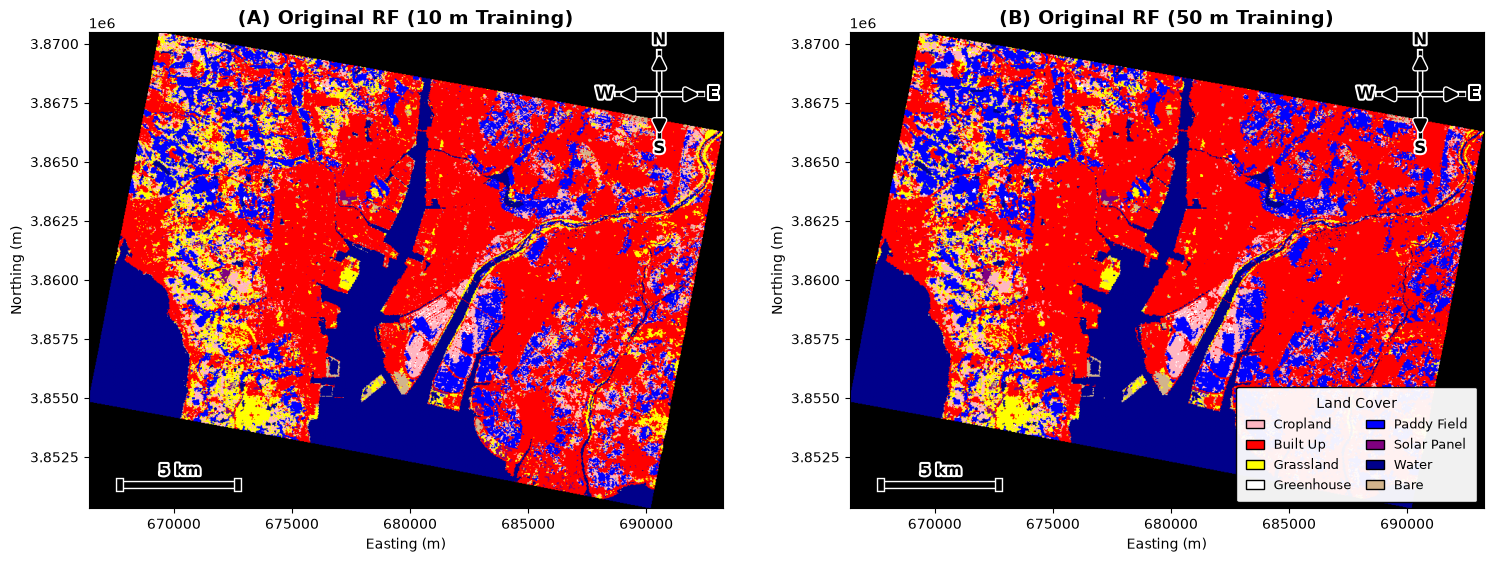

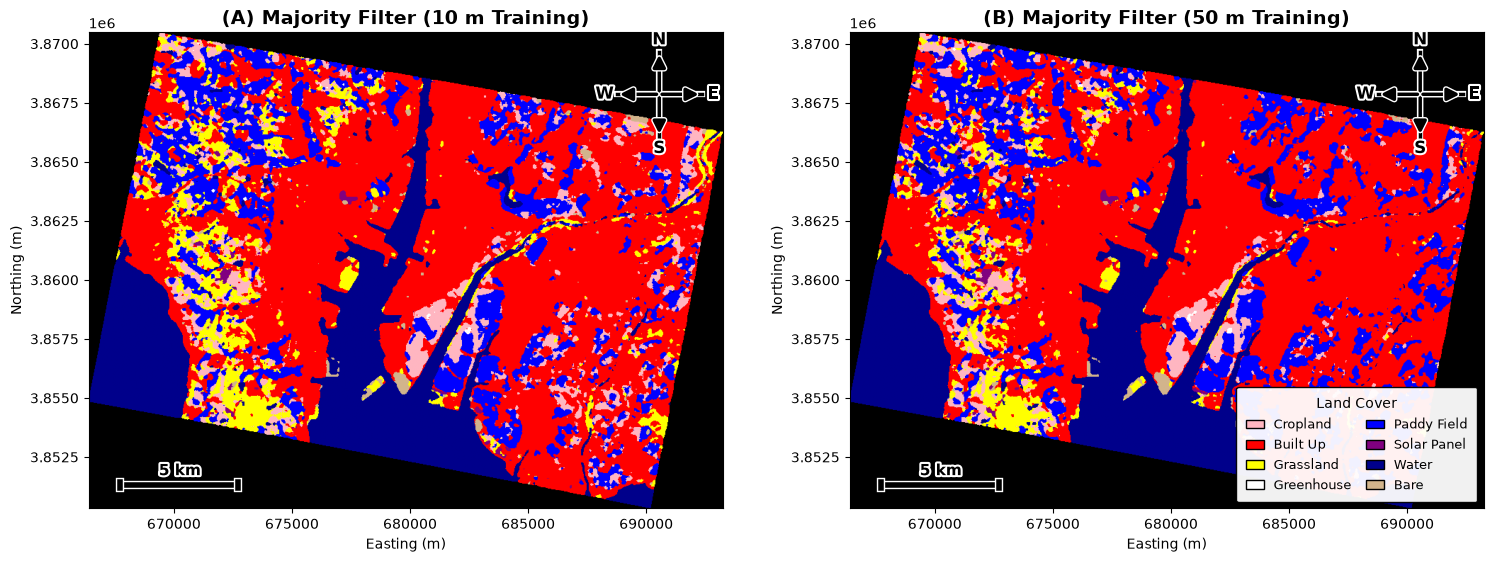

In [15]:
# =============================================================================
# COMPARISON OF 10 m AND 50 m TRAINING DATASETS
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import numpy as np

# ---------------------------------------------------------------------
# Color lookup table
# ---------------------------------------------------------------------

lut = np.zeros((len(CLASSES) + 1, 3), dtype=float)

for cls, idx in class_to_id.items():
    lut[idx] = mcolors.to_rgb(color_map[clean(cls)])

def to_rgb(img):
    return lut[img]

rgb_original_10 = to_rgb(pred_map_10)
rgb_original_50 = to_rgb(pred_map_50)

rgb_majority_10 = to_rgb(pred_majority_10)
rgb_majority_50 = to_rgb(pred_majority_50)

# =============================================================================
# MAP DECORATIONS
# =============================================================================

def add_scalebar(ax, length=5000, location=(0.05, 0.05), linewidth=4):

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x = xmin + (xmax - xmin) * location[0]
    y = ymin + (ymax - ymin) * location[1]

    line = ax.plot(
        [x, x + length],
        [y, y],
        color="black",
        linewidth=linewidth,
        solid_capstyle="butt",
        zorder=100
    )[0]

    line.set_path_effects([
        pe.Stroke(linewidth=linewidth + 2, foreground="white"),
        pe.Normal()
    ])

    for xx in [x, x + length]:
        tick = ax.plot(
            [xx, xx],
            [y - 120, y + 120],
            color="black",
            linewidth=linewidth,
            zorder=100
        )[0]

        tick.set_path_effects([
            pe.Stroke(linewidth=linewidth + 2, foreground="white"),
            pe.Normal()
        ])

    txt = ax.text(
        x + length / 2,
        y + 250,
        f"{length/1000:.0f} km",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom",
        color="black",
        zorder=101
    )

    txt.set_path_effects([
        pe.Stroke(linewidth=3, foreground="white"),
        pe.Normal()
    ])


def add_north_arrow(ax, location=(0.90, 0.87), size=1800):

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    cx = xmin + (xmax - xmin) * location[0]
    cy = ymin + (ymax - ymin) * location[1]

    lw = 2.5

    v = ax.plot(
        [cx, cx],
        [cy - size, cy + size],
        color="black",
        linewidth=lw,
        zorder=100
    )[0]

    v.set_path_effects([
        pe.Stroke(linewidth=lw + 2, foreground="white"),
        pe.Normal()
    ])

    h = ax.plot(
        [cx - size, cx + size],
        [cy, cy],
        color="black",
        linewidth=lw,
        zorder=100
    )[0]

    h.set_path_effects([
        pe.Stroke(linewidth=lw + 2, foreground="white"),
        pe.Normal()
    ])

    for dx, dy in [(0, size), (0, -size), (size, 0), (-size, 0)]:

        ann = ax.annotate(
            "",
            xy=(cx + dx, cy + dy),
            xytext=(cx, cy),
            arrowprops=dict(
                arrowstyle="-|>",
                lw=lw,
                color="black",
                mutation_scale=18
            ),
            zorder=101
        )

        ann.arrow_patch.set_path_effects([
            pe.Stroke(linewidth=lw + 2, foreground="white"),
            pe.Normal()
        ])

    labels = [
        ("N", 0, size + 500),
        ("S", 0, -(size + 500)),
        ("E", size + 500, 0),
        ("W", -(size + 500), 0),
    ]

    for txt, dx, dy in labels:

        t = ax.text(
            cx + dx,
            cy + dy,
            txt,
            fontsize=12,
            fontweight="bold",
            ha="center",
            va="center",
            color="black",
            zorder=102
        )

        t.set_path_effects([
            pe.Stroke(linewidth=3, foreground="white"),
            pe.Normal()
        ])

# ---------------------------------------------------------------------
# Image extent
# ---------------------------------------------------------------------

left = transform.c
top = transform.f
right = left + w * transform.a
bottom = top + h * transform.e

extent = [left, right, bottom, top]

# ---------------------------------------------------------------------
# Legend (create once)
# ---------------------------------------------------------------------

legend = [
    mpatches.Patch(
        facecolor=color_map[clean(c)],
        edgecolor="black",
        label=clean(c).replace("-", " ").title()
    )
    for c in CLASSES
]

# =============================================================================
# FIGURE 1
# ORIGINAL CLASSIFICATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(rgb_original_10, extent=extent)
axes[0].set_title("(A) Original RF (10 m Training)", fontsize=14, fontweight="bold")

axes[1].imshow(rgb_original_50, extent=extent)
axes[1].set_title("(B) Original RF (50 m Training)", fontsize=14, fontweight="bold")

for ax in axes:
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    add_scalebar(ax, length=5000)
    add_north_arrow(ax)

axes[1].legend(
    handles=legend,
    title="Land Cover",
    loc="lower right",
    ncol=2,
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="black",
    borderpad=0.8,
    columnspacing=1.2,
    handlelength=1.4
)


fig.savefig(
    "comparison_original_10m_vs_50m.png",
    dpi=300
)

plt.show()

# =============================================================================
# FIGURE 2
# MAJORITY FILTER
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(rgb_majority_10, extent=extent)
axes[0].set_title("(A) Majority Filter (10 m Training)", fontsize=14, fontweight="bold")

axes[1].imshow(rgb_majority_50, extent=extent)
axes[1].set_title("(B) Majority Filter (50 m Training)", fontsize=14, fontweight="bold")

for ax in axes:
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    add_scalebar(ax, length=5000)
    add_north_arrow(ax)

axes[1].legend(
    handles=legend,
    title="Land Cover",
    loc="lower right",
    ncol=2,
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="black",
    borderpad=0.8,
    columnspacing=1.2,
    handlelength=1.4
)

fig.savefig(
    "comparison_majority_10m_vs_50m.png",
    dpi=300
)

plt.show()